<a href="https://colab.research.google.com/github/frankljr/IT480-FA26/blob/main/assignment2_transferlearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2: Transfer Learning Across Two Datasets

**Name:** *James Franklin*

**Prerequisite:** Transfer Learning lecture (frozen feature extraction)

This assignment uses frozen transfer learning, exactly what was covered in lecture: load a pretrained base, freeze it, add a new head, train only that. You'll do this twice, on two different datasets, and compare the results.

Data loading is provided for you below. Everything after that, building the model, training, evaluating, and reflecting, is yours to write, following the general instructions in each section.

**Submission:** GitHub repo URL and this notebook's URL on Canvas.

## Setup — Imports

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

---
# Part 1: Fire/Smoke Detection

## 1A — Load the Data

In [ ]:
!pip install legacy-cgi --quiet
!pip install opendatasets --quiet

import opendatasets as od
od.download("https://www.kaggle.com/datasets/phylake1337/fire-dataset")

for root, dirs, files in os.walk("fire-dataset"):
    print(root, "->", dirs[:5], f"({len(files)} files)")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: frankljr
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/phylake1337/fire-dataset


100%|██████████| 387M/387M [00:07<00:00, 57.7MB/s]



fire-dataset -> ['fire_dataset'] (0 files)
fire-dataset/fire_dataset -> ['fire_images', 'non_fire_images'] (0 files)
fire-dataset/fire_dataset/fire_images -> [] (755 files)
fire-dataset/fire_dataset/non_fire_images -> [] (244 files)


In [ ]:
data_dir_fire = "fire-dataset/fire_dataset"

img_size = (224, 224)
batch_size = 32

train_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_fire = tf.data.experimental.cardinality(val_test_raw_fire)
test_raw_fire = val_test_raw_fire.take(val_test_batches_fire // 2)
val_raw_fire = val_test_raw_fire.skip(val_test_batches_fire // 2)

class_names_fire = train_raw_fire.class_names
print("Class names:", class_names_fire)

Found 999 files belonging to 2 classes.
Using 700 files for training.
Found 999 files belonging to 2 classes.
Using 299 files for validation.
Class names: ['fire_images', 'non_fire_images']


## 1B — Inspect the Data

Before doing anything else, take a real look at what you loaded. How many images does each class have? Is there anything about the data itself that might affect how you should split it, or how you should interpret your model's results later?

Write whatever code you need to answer this for yourself.

In [ ]:
class_counts = {}

for class_name in class_names_fire:
  class_counts[class_name] = 0

for images, labels in train_raw_fire:
  for label in labels.numpy():
    class_counts[class_names_fire[label]] += 1

print("Training set class distribution:")
for class_name, count in class_counts.items():
  print(f"{class_name}: {count} images")



Training set class distribution:
fire_images: 538 images
non_fire_images: 162 images


*What did you notice about this dataset? Does it change how you'll approach the next steps?*

Answer: This dataset consists of 2 classes: fire_images & non_fire_images. These classes appear imbalances with the fire_images class containing significantly more images than the non_fire_images class. This could greatly affect the models accuracy and thus also the confusion matrix. Extra attention to detail will be required when constructing such to see how well the model detects actual fires.


## 1C — Build a Frozen Transfer Learning Model

Using MobileNetV2 as your pretrained base:
- Freeze the base model entirely
- Add a new output layer appropriate for this task (think about how many classes you're predicting, and what that means for your output layer's size, activation, and loss function)
- Remember the pattern from lecture for how the base model should be called

Preprocess your data (`train_raw_fire`, `val_raw_fire`, `test_raw_fire`) using MobileNetV2's expected preprocessing before building your model.

In [ ]:
def preprocess_fire(images, labels):
  images = preprocess_input(images)
  return images, labels

train_fire = train_raw_fire.map(preprocess_fire)
val_fire = val_raw_fire.map(preprocess_fire)
test_fire = test_raw_fire.map(preprocess_fire)


In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

inputs = base_model.input
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
outputs = Dense(2, activation='softmax')(x)

model = Model(inputs, outputs)
model.summary()



Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)



## 1D — Train and Evaluate

In [ ]:
history = model.fit(
    train_fire,
    validation_data=val_fire,
    epochs=10
)



Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - accuracy: 0.8871 - loss: 0.2835 - val_accuracy: 0.9496 - val_loss: 0.1274
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.9757 - loss: 0.0869 - val_accuracy: 0.9784 - val_loss: 0.0822
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.9843 - loss: 0.0629 - val_accuracy: 0.9712 - val_loss: 0.0725
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.9871 - loss: 0.0509 - val_accuracy: 0.9928 - val_loss: 0.0420
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.9900 - loss: 0.0433 - val_accuracy: 0.9928 - val_loss: 0.0424
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.9943 - loss: 0.0383 - val_accuracy: 0.9784 - val_loss: 0.0582
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.9957 - loss: 0.0343 - val_accuracy: 0.9712 - val_loss: 0.0609
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.9957 - loss: 0.0299 - val_accuracy: 0.9784 - val_loss:

In [ ]:
val_loss, val_accuracy = model.evaluate(val_fire)
test_loss , test_accuracy = model.evaluate(test_fire)

print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy}")


5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 891ms/step - accuracy: 0.9784 - loss: 0.0558
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.9750 - loss: 0.0619
Validation Accuracy: 0.9784
Test Accuracy: 0.9750000238418579


## 1E — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** In this context, is a false negative (missing a real fire) or a false positive (a false alarm) more costly? How might that change the decision threshold you'd actually use in practice, rather than the default 0.5?

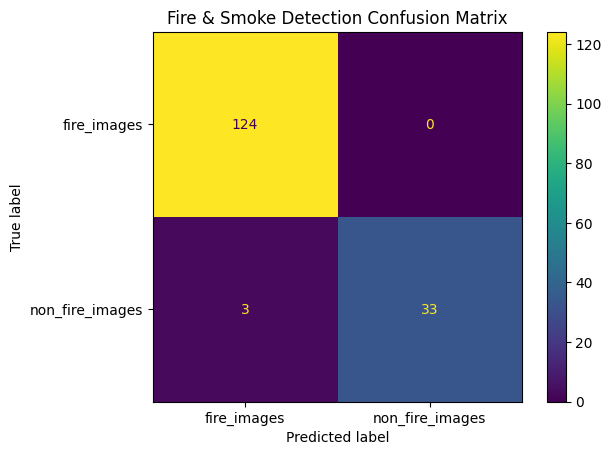

In [ ]:
y = []
y_pred =[]

for images, labels in test_fire:
  predictions = model.predict(images, verbose=0)
  y.extend(labels.numpy())
  y_pred.extend(np.argmax(predictions, axis=1))

matrix = confusion_matrix(y, y_pred)
display = ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=class_names_fire
)

display.plot()
plt.title("Fire & Smoke Detection Confusion Matrix")
plt.show()




* *italicized text*Your answer:* In this circumstance, a false negative (missing a real fire) would be more costly than the likelihood of a false positive (no actual fire). This is due to the fact that in a scenario where a fall positive is presented, this would not pose any real threat nor result in any dire consequences; meaning a false positive is almost completely negligible. Missing a false negative however, is more costly as it measn we failed to detect a real alarm which may result in serious consequences regarding life and safety. Keeping this in mind, it would be better to use a lower decision threshold than 0.5 to make the model more likely to identify potential fires.




---
# Part 2: Satellite Land-Use Classification (EuroSAT)

## 2A — Load the Data

In [ ]:
!wget -q "https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip?download=1" -O EuroSAT_RGB.zip
!unzip -q EuroSAT_RGB.zip -d eurosat_data

data_dir_sat = "eurosat_data/EuroSAT_RGB"
print(os.listdir(data_dir_sat))

['PermanentCrop', 'Highway', 'Industrial', 'River', 'AnnualCrop', 'Pasture', 'HerbaceousVegetation', 'Residential', 'Forest', 'SeaLake']


In [ ]:
train_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_sat = tf.data.experimental.cardinality(val_test_raw_sat)
test_raw_sat = val_test_raw_sat.take(val_test_batches_sat // 2)
val_raw_sat = val_test_raw_sat.skip(val_test_batches_sat // 2)

class_names_sat = train_raw_sat.class_names
print("Class names:", class_names_sat)

Found 27000 files belonging to 10 classes.
Using 18900 files for training.
Found 27000 files belonging to 10 classes.
Using 8100 files for validation.
Class names: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## 2B — Build a Frozen Transfer Learning Model

Same overall pattern as Part 1, but look closely at what's different about this task before you build your output layer, activation, and loss function.

Preprocess `train_raw_sat`, `val_raw_sat`, and `test_raw_sat` first.

In [ ]:
def preprocess_sat(images, labels):
  images = preprocess_input(images)
  return images, labels

train_sat = train_raw_sat.map(preprocess_sat)
val_sat = val_raw_sat.map(preprocess_sat)
test_sat = test_raw_sat.map(preprocess_sat)



In [ ]:
base_model_sat = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model_sat.trainable = False

inputs = base_model_sat.input
x = base_model_sat(inputs, training=False)
x = GlobalAveragePooling2D()(x)
outputs = Dense(10, activation='softmax')(x)

model_sat = Model(inputs, outputs)
model_sat.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
model_sat.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)



## 2C — Train and Evaluate

In [ ]:
history_sat = model_sat.fit(
    train_sat,
    validation_data=val_sat,
    epochs=10
)





Epoch 1/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 941s 2s/step - accuracy: 0.8762 - loss: 0.3760 - val_accuracy: 0.9272 - val_loss: 0.2238
Epoch 2/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 1157s 2s/step - accuracy: 0.9338 - loss: 0.1963 - val_accuracy: 0.9353 - val_loss: 0.1938
Epoch 3/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 931s 2s/step - accuracy: 0.9463 - loss: 0.1599 - val_accuracy: 0.9388 - val_loss: 0.1876
Epoch 4/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 943s 2s/step - accuracy: 0.9533 - loss: 0.1392 - val_accuracy: 0.9408 - val_loss: 0.1835
Epoch 5/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 954s 2s/step - accuracy: 0.9606 - loss: 0.1221 - val_accuracy: 0.9400 - val_loss: 0.1789
Epoch 6/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 895s 2s/step - accuracy: 0.9637 - loss: 0.1107 - val_accuracy: 0.9371 - val_loss: 0.1873
Epoch 7/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 899s 2s/step - accuracy: 0.9683 - loss: 0.0997 - val_accuracy: 0.9386 - val_loss: 0.1850
Epoch 8/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 901s 2s/step - accuracy: 0.9709 - loss: 0.0920 - val_acc

In [ ]:
val_loss_sat, val_accuracy_sat = model_sat.evaluate(val_sat)
test_loss_sat, test_accuracy_sat = model_sat.evaluate(test_sat)

print(f"validation Accuracy: {val_accuracy_sat:.4f}")
print(f"Test Accuracy: {test_accuracy_sat:.4f}")



127/127 ━━━━━━━━━━━━━━━━━━━━ 158s 1s/step - accuracy: 0.9440 - loss: 0.1736
127/127 ━━━━━━━━━━━━━━━━━━━━ 156s 1s/step - accuracy: 0.9409 - loss: 0.1743
validation Accuracy: 0.9440
Test Accuracy: 0.9409


## 2D — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** Which land-use classes get confused most often? Does that make visual sense to you?

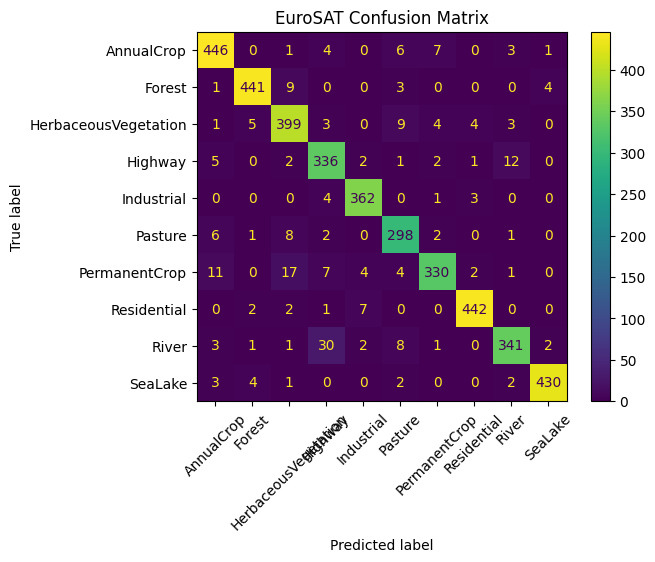

In [ ]:
y_sat = []
y_pred_sat = []

for images, labels in test_sat:
  predictions = model_sat.predict(images, verbose=0)
  y_sat.extend(labels.numpy())
  y_pred_sat.extend(np.argmax(predictions, axis=1))

matrix_sat = confusion_matrix(y_sat, y_pred_sat)
display_sat = ConfusionMatrixDisplay(
    confusion_matrix=matrix_sat,
    display_labels=class_names_sat
)

display_sat.plot(xticks_rotation=45)
plt.title("EuroSAT Confusion Matrix")
plt.show()


*Your answer:* The most confused classes out of this model include both the River and Highway Classed with 30 River images being classified as within the Highway class. Whilst there is a slight confusion between the PermanentCrop and HerbaceousVegetation classes, these errors whilst visual are predictable due to the different land-use classes that have similar patterns and shapes; This is most notably viewed top down from a satellite image.




---
# Part 3: Compare the Two Domains

Fill in your own results:

| | Fire/Smoke | EuroSAT |
|---|---|---|
| Validation Accuracy |0.9784 |0.9440 |
| Test Accuracy |0.9750 |0.9409 |

**Answer:**
1. MobileNetV2 was originally trained on ImageNet, ordinary ground-level photos of everyday objects. Which of your two datasets do you think is the closer match to that original training, and which is the bigger mismatch? Use your actual results as evidence.
2. For each dataset, do you think there's room for improvement if you could adjust part of the pretrained model itself, rather than just the new layer on top? Would you expect that to matter more for one dataset than the other? Why?

*Your answers:*
1. The fire/smoke dataset is a much closer match to that of ImageNet in comparison to EuroSAT due to it containing ground-level images populated with objects/scenes that appear more like to the images found within the ImageNet dataset. This is further supported through the fire/smoke model obtaining a higher test accuracy than the EuroSAT model.

2. There is room for improvement for both datasets; This achieved when fine-tuning a portion of the pretrained MobileNetV2 layers as opposed to the entire base frozen. I would expect this improve the EuroSAT model more due to there being a bigger difference in the number of satellite images from ImageNet compared to the fire/smoke model. Allowing the model to adjust its pretrained features would help it learn featurs that are more specific to land-use patterns.



---
# Part 4: Reflection

Answer in 4 to 6 sentences:

1. Did anything about the Fire dataset's composition affect how you approached splitting or evaluating it? Explain.
2. What's the actual difference between the output layer, activation, and loss function you used in Part 1 versus Part 2? Why does that difference exist?
3. Based on your results, does a pretrained model's usefulness depend only on how good the model is, or also on how well its original training matches your task? Explain using your own two results as evidence.

*Your answers:*
The fire/smoke class imbalance had affected how i initially approached the envaluation due to the accuracy not showing how well the model could detect actuals fires; for this reason we also had to consider the results that had come up from the confusion matrix. The model utilized a 2-neuron output layer set with softmax activation, in difference to the EuroSAT model that used a 10-neuron output layer also set with softmax activation. The number of neurons for that model matches the 10 seperate classes that used spare categorical crossentropy due to the integer class labels. It is worth noting my fire model contained no false negatives within the test set. The results showed that the pretrained MobileNetV2 model performed much better on fire/smoke as opposed to EuroSAT. This suggests that the transfer learnings not onyl depends on the wuality of the pretrained model but also that of how similar the new dataset is to the original ImageNet training data.
---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.